In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

df_raw = pd.read_csv("data/symbol_info_3-25.csv")
df_raw

,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,payout_ratio,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp
0,AAPL,Apple Inc.,Technology,Consumer Electronics,3278873821184,3321891913728,218.270004,214.100006,260.100006,164.080002,...,0.1571,52181373,2.71,NMS,NMS,United States,0,0,1,2025-03-22 04:50:05
1,MSFT,Microsoft Corporation,Technology,Software - Infrastructure,2908619014144,2939973795840,391.260010,386.839996,468.350006,376.910004,...,0.2482,22370941,2.68,NMS,NMS,United States,0,0,1,2025-03-22 04:50:07
2,NVDA,NVIDIA Corporation,Technology,Semiconductors,2892136185856,2838940090368,117.699997,118.529999,153.130005,75.606003,...,0.0116,271988186,0.84,NMS,NMS,United States,0,0,1,2025-03-22 04:50:06
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,Internet Retail,2079374704640,2133579530240,196.210007,194.949997,242.520004,151.610001,...,0.0000,38226331,1.78,NMS,NMS,United States,0,0,1,2025-03-22 04:50:08
4,GOOGL,Alphabet Inc.,Communication Services,Internet Content & Information,1996906430464,1931518148608,163.990005,162.800003,207.050003,147.220001,...,0.0746,29147868,2.01,NMS,NMS,United States,0,0,1,2025-03-22 04:50:09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,TREX,"Trex Company, Inc.",Industrials,Building Products & Equipment,6402809856,6622597632,59.430000,59.750000,100.769997,52.750000,...,0.0000,1457886,3.74,NYQ,NYQ,United States,0,0,1,2025-03-22 05:10:44
996,DINO,HF Sinclair Corporation,Energy,Oil & Gas Refining & Marketing,6385117696,8783124480,33.529999,33.889999,64.160004,29.850000,...,2.1978,3245270,3.08,NYQ,NYQ,United States,0,0,1,2025-03-22 04:57:18
997,VFC,V.F. Corporation,Consumer Cyclical,Apparel Manufacturing,6377310208,10759408640,16.370001,16.250000,29.020000,11.000000,...,5.3667,7199263,3.98,NYQ,NYQ,United States,0,0,1,2025-03-22 05:14:56
998,BPOP,"Popular, Inc.",Financial Services,Banks - Regional,6359964672,852976576,91.370003,90.220001,106.809998,80.599998,...,0.2991,541118,2.26,NMS,NMS,United States,0,0,1,2025-03-22 05:00:28


In [130]:
df = df_raw.copy()

#
df = df[
    (df["is_etf"] == 0) &
    (df["is_fund"] == 0) &
    (df["is_actively_trading"] == 1) &
    (df["market_cap"] > 0) &
    (df["total_revenue"] > 0)
].copy()

#transform into billions
df["market_cap_b"] = df["market_cap"] / 1e9
df["enterprise_value_b"] = df["enterprise_value"] / 1e9
df["revenue_b"] = df["total_revenue"] / 1e9
df["net_income_b"] = df["net_income"] / 1e9
df["free_cashflow_b"] = df["free_cashflow"] / 1e9

#percentage
df["profit_margin_pct"] = df["profit_margins"] * 100
df["revenue_growth_pct"] = df["revenue_growth"] * 100
df["earnings_growth_pct"] = df["earnings_growth"] * 100
df["return_on_assets_pct"] = df["return_on_assets"] * 100
df["return_on_equity_pct"] = df["return_on_equity"] * 100

df["dividend_yield_pct"] = df["dividend_yield"]
df = df.replace([np.inf, -np.inf], np.nan)

# Reusable formatter: show numbers as billions with one decimal.
def billions_formatter(x, pos):
    return f"{x:,.0f}B"

# Reusable formatter: show percentages with no decimal places.
def pct_formatter(x, pos):
    return f"{x:.0f}%"

# Reusable helper to remove unnecessary chart borders.
# This gives a cleaner report-style chart.
def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return ax

# Reusable helper to annotate bars in a horizontal bar chart.
def annotate_hbar(ax, fmt="{:.1f}"):
    for patch in ax.patches:
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2
        ax.text(width, y, "  " + fmt.format(width), va="center", fontsize=9)

In [133]:
#1)
#select raws with 'sector'='Basic Materials'
grouped = df.groupby('sector')
BM=grouped.get_group('Basic Materials')

# 2 plotting histogram

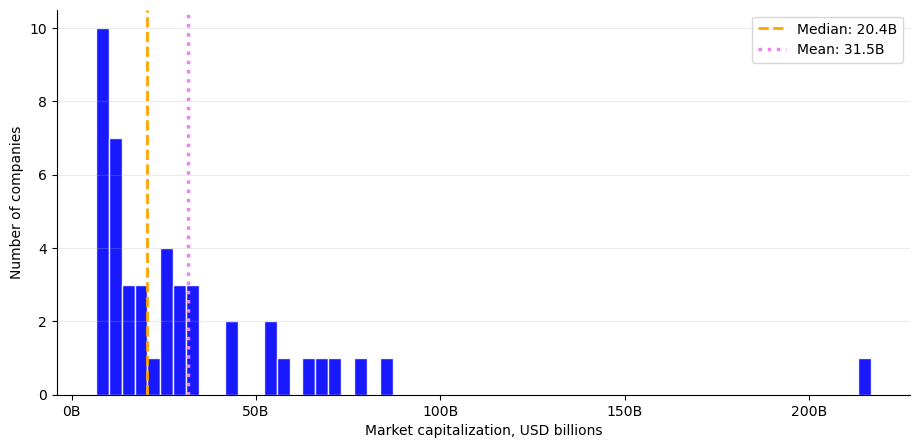

In [135]:
#2)
#plotting the histogram
market_cap = BM["market_cap_b"].dropna()

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist( market_cap, bins=60, color='blue', edgecolor='white', alpha=0.9)
#naming the axes and adding billions sign on the x axis
ax.set_xlabel("Market capitalization, USD billions")
ax.set_ylabel("Number of companies")
ax.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
ax.grid(axis="y", alpha=0.25)

#adding median and mean of the sector
median_value = market_cap.median()
ax.axvline(median_value, color="orange", linestyle="--", linewidth=2, label=f"Median: {median_value:,.1f}B")
mean_value = market_cap.mean()
ax.axvline(mean_value, color="violet", linestyle=":", linewidth=2.5, label=f"Mean: {mean_value:,.1f}B")
#adding legend of median and mean
ax.legend()
#removing upper and right lateral lines
clean_spines(ax)
plt.show()


Interpretation of the histogram: the mean is larger than the median so the histogram is positively skewed. This means that most copanies have relatively low market capitalization. 

{'whiskers': [<matplotlib.lines.Line2D at 0x146be7390>,
 'caps': [<matplotlib.lines.Line2D at 0x146be7610>,
 'boxes': [<matplotlib.lines.Line2D at 0x146be7250>],
 'medians': [<matplotlib.lines.Line2D at 0x146be7890>],
 'fliers': [<matplotlib.lines.Line2D at 0x146be79d0>],
 'means': []}

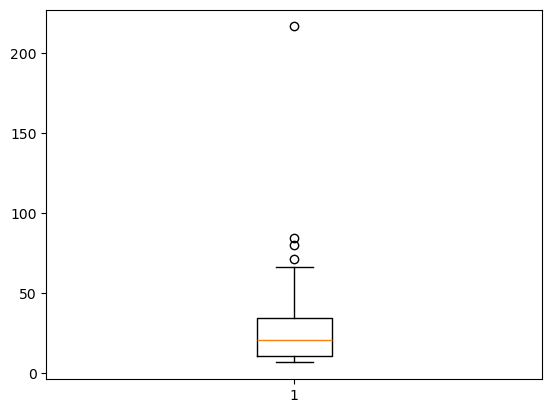

In [136]:
plt.boxplot(BM['market_cap_b'])

Boxplot interpretation: the preview statement is confirmed by the boxplot and ithere are a few outliers.

{'whiskers': [<matplotlib.lines.Line2D at 0x146c35d10>,
 'caps': [<matplotlib.lines.Line2D at 0x146c35f90>,
 'boxes': [<matplotlib.lines.Line2D at 0x146c35bd0>],
 'medians': [<matplotlib.lines.Line2D at 0x146c36210>],
 'fliers': [],
 'means': []}

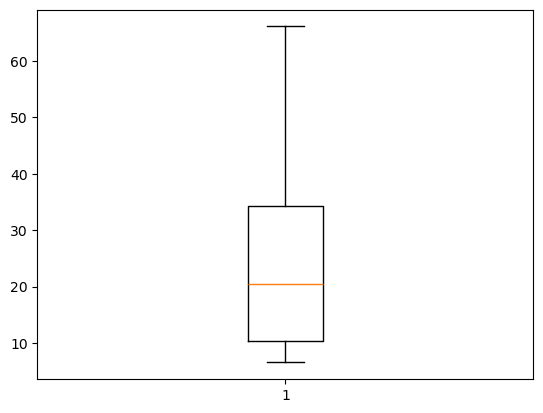

In [137]:
#boxplot without outliers
plt.boxplot(BM['market_cap_b'], showfliers=False)



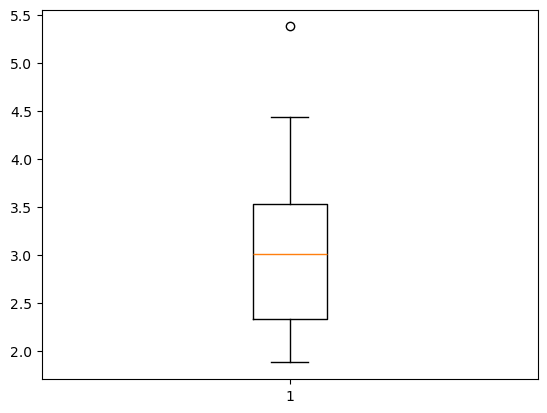

In [138]:
#log for a clearer understanding of the data
BMlog=np.log(BM["market_cap_b"])
plt.boxplot(BMlog)

#removing the outlier
Q1 = BMlog.quantile(0.25)
Q3 = BMlog.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
BM_clean1= BM[(BMlog >= lower) & (BMlog <= upper)]

comment: the previews outliers where very near the boxplot, the logaritm allowed me to reduce the number of outliers. The unique outlier was deleted.

## 3 subcharts by industries

Text(0, 0.5, 'Sector')

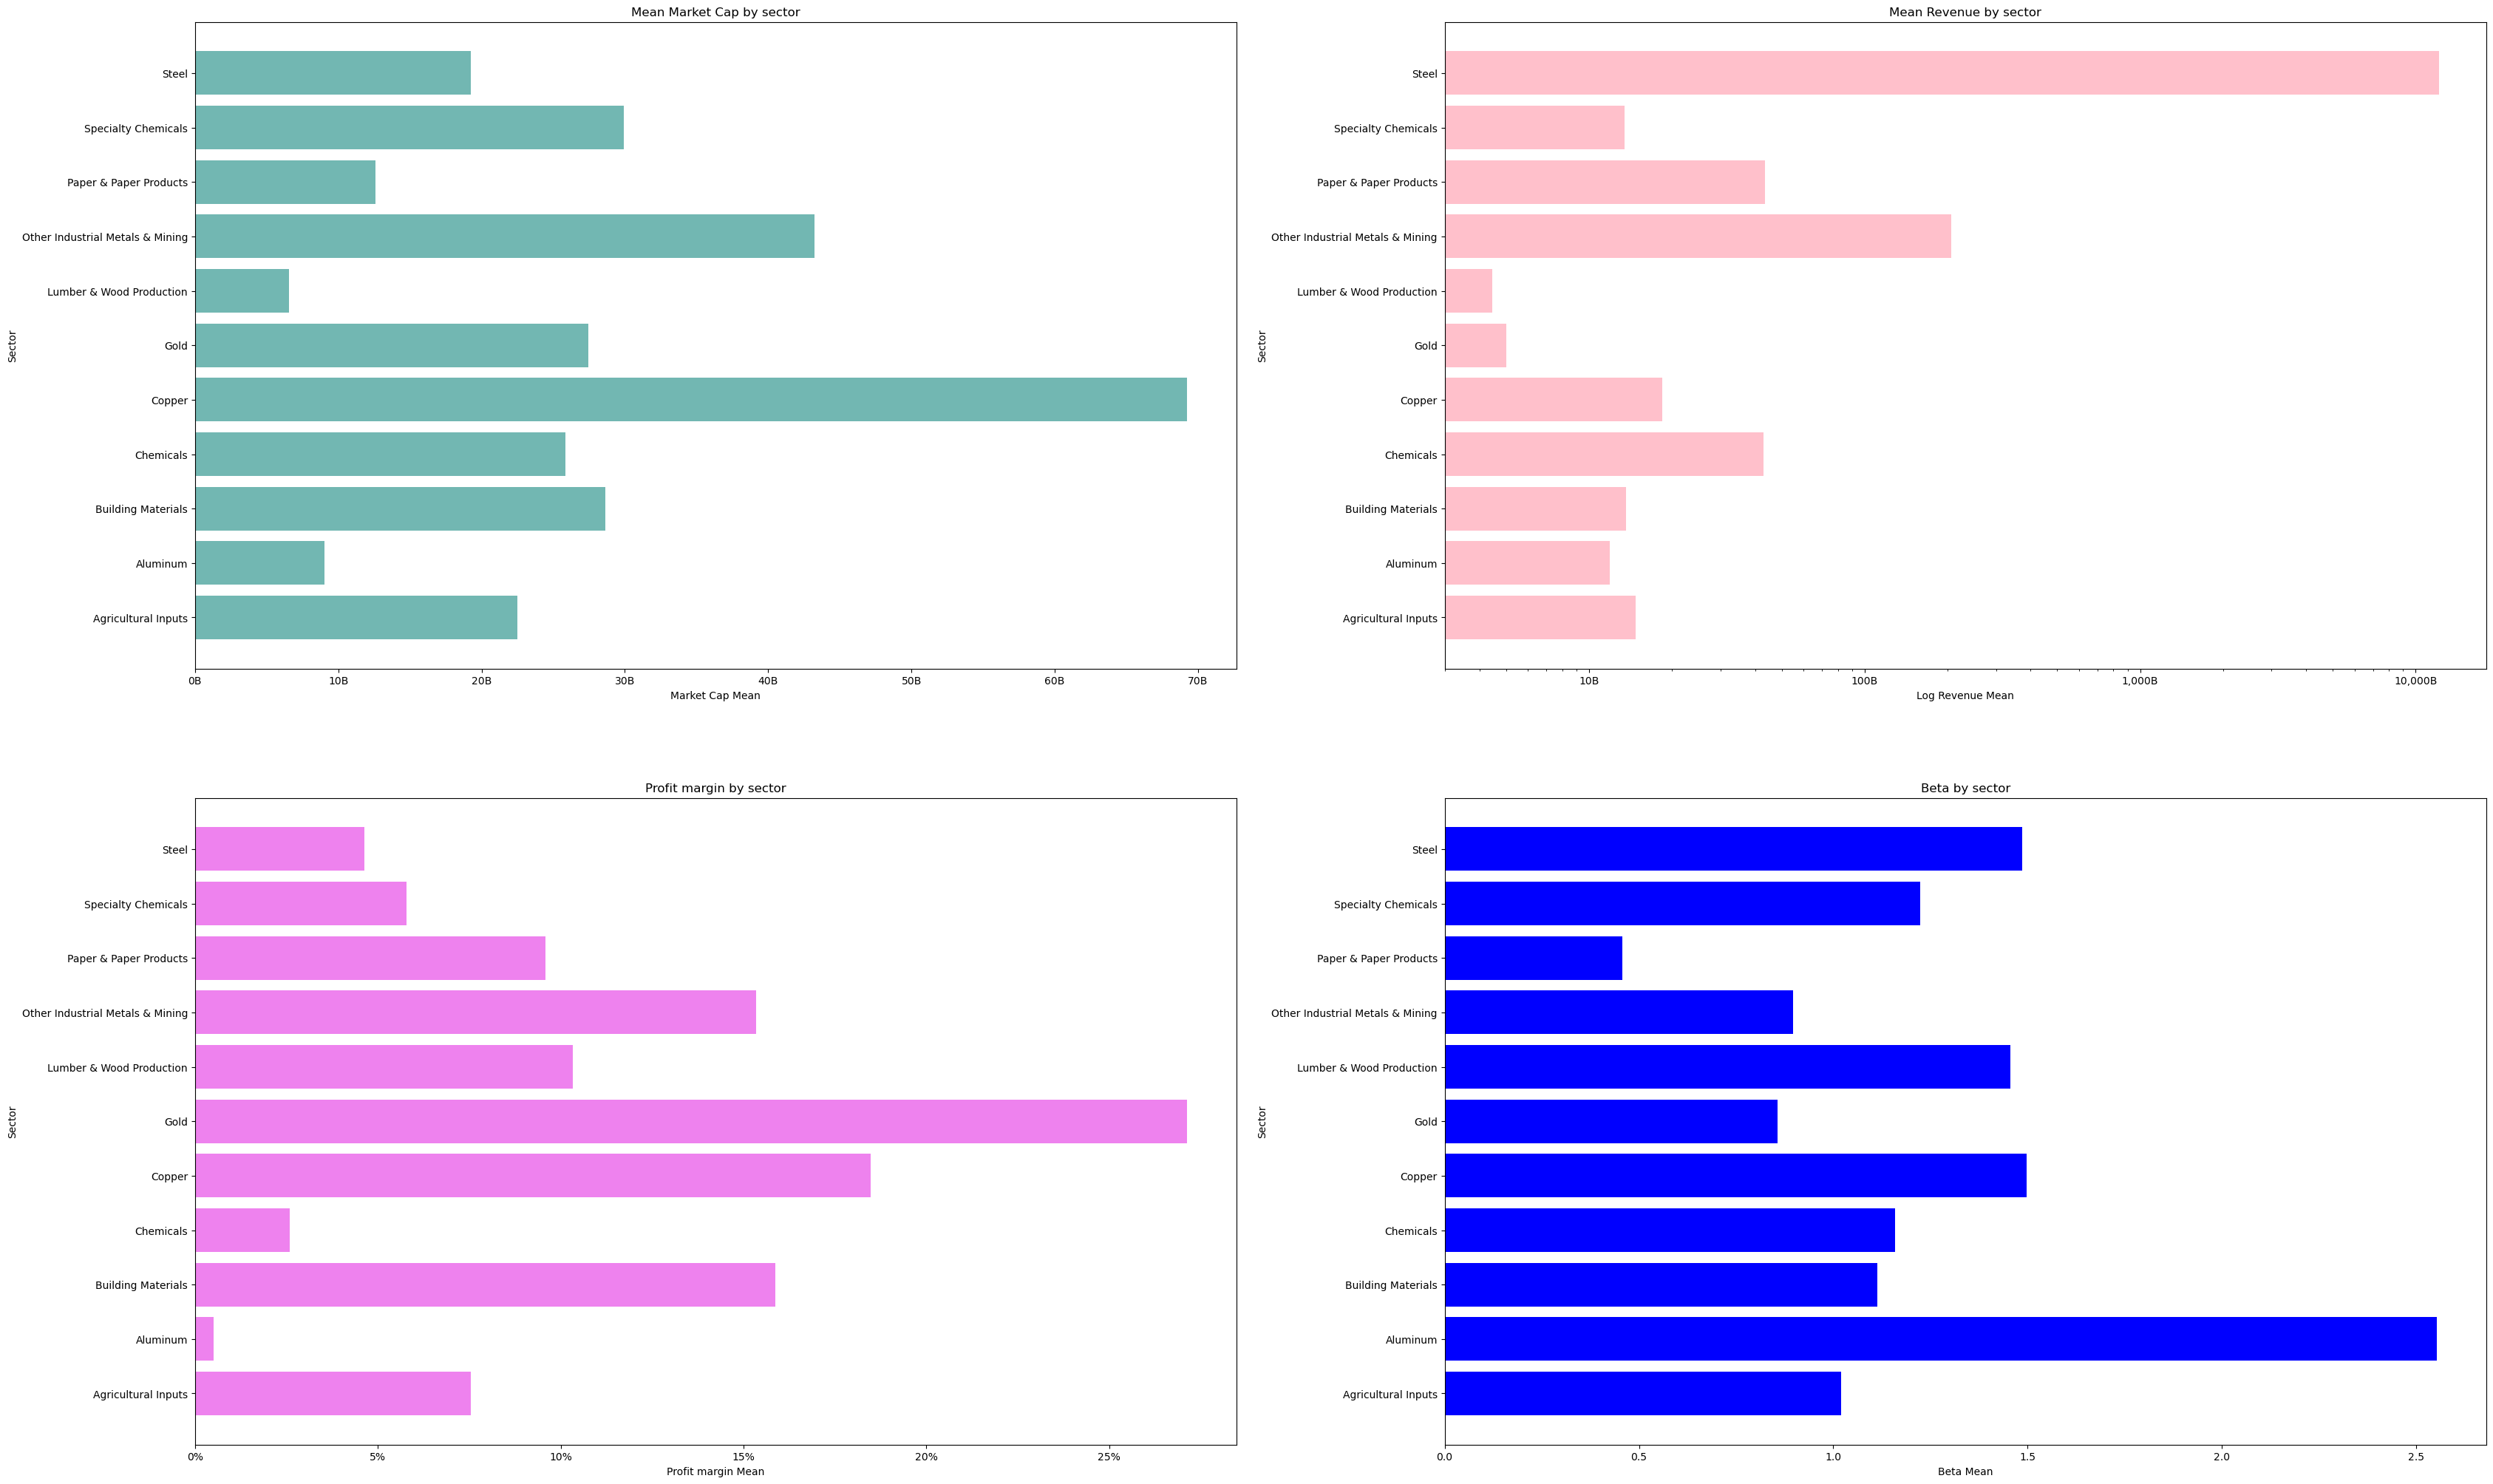

In [187]:
#3
#means by industries
mean_market_cap=BM_clean1.groupby("industry")["market_cap_b"].mean()
mean_revenue=BM_clean1.groupby("industry")["revenue_b"].mean()
mean_profit=BM_clean1.groupby("industry")["profit_margin_pct"].mean()
mean_beta=BM_clean1.groupby("industry")["beta"].mean()

#creating the single figure
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(40, 25),
    sharey=False
)
#flatten the array
axes = axes.flatten()

#giving names to axis
ax_cap = axes[0]
ax_rev = axes[1]
ax_profit = axes[2]
ax_beta = axes[3]

#left upper chart
ax_cap.barh(
    mean_market_cap.index,          
    mean_market_cap.values,
    color="#72B7B2"              
)
ax_cap.set_title("Mean Market Cap by sector")
ax_cap.set_xlabel("Market Cap Mean")
ax_cap.set_ylabel("Sector")
ax_cap.xaxis.set_major_formatter(FuncFormatter(billions_formatter))
#rigth upper chart

ax_rev.barh(
    mean_revenue.index,          
    mean_revenue.values,
    color="pink"              
)
ax_rev.set_xscale("log") #to better see the values
ax_rev.set_title("Mean Revenue by sector")
ax_rev.set_xlabel("Log Revenue Mean")
ax_rev.set_ylabel("Sector")
ax_rev.xaxis.set_major_formatter(FuncFormatter(billions_formatter))

#left lower chart
ax_profit.barh(
    mean_profit.index,          
    mean_profit.values,
    color="violet"              
)
ax_profit.set_title("Profit margin by sector")
ax_profit.set_xlabel("Profit margin Mean")
ax_profit.set_ylabel("Sector")
ax_profit.xaxis.set_major_formatter(FuncFormatter(pct_formatter))

#right lower chart
ax_beta.barh(
    mean_beta.index,          
    mean_beta.values,
    color="blue"              
)
ax_beta.set_title("Beta by sector")
ax_beta.set_xlabel("Beta Mean")
ax_beta.set_ylabel("Sector")


## 4. boxplots

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Specialty Chemicals'),
  Text(1, 0, 'Copper'),
  Text(2, 0, 'Building Materials'),
  Text(3, 0, 'Gold'),
  Text(4, 0, 'Other Industrial Metals & Mining'),
  Text(5, 0, 'Agricultural Inputs'),
  Text(6, 0, 'Steel'),
  Text(7, 0, 'Chemicals'),
  Text(8, 0, 'Paper & Paper Products'),
  Text(9, 0, 'Aluminum'),
  Text(10, 0, 'Lumber & Wood Production')])

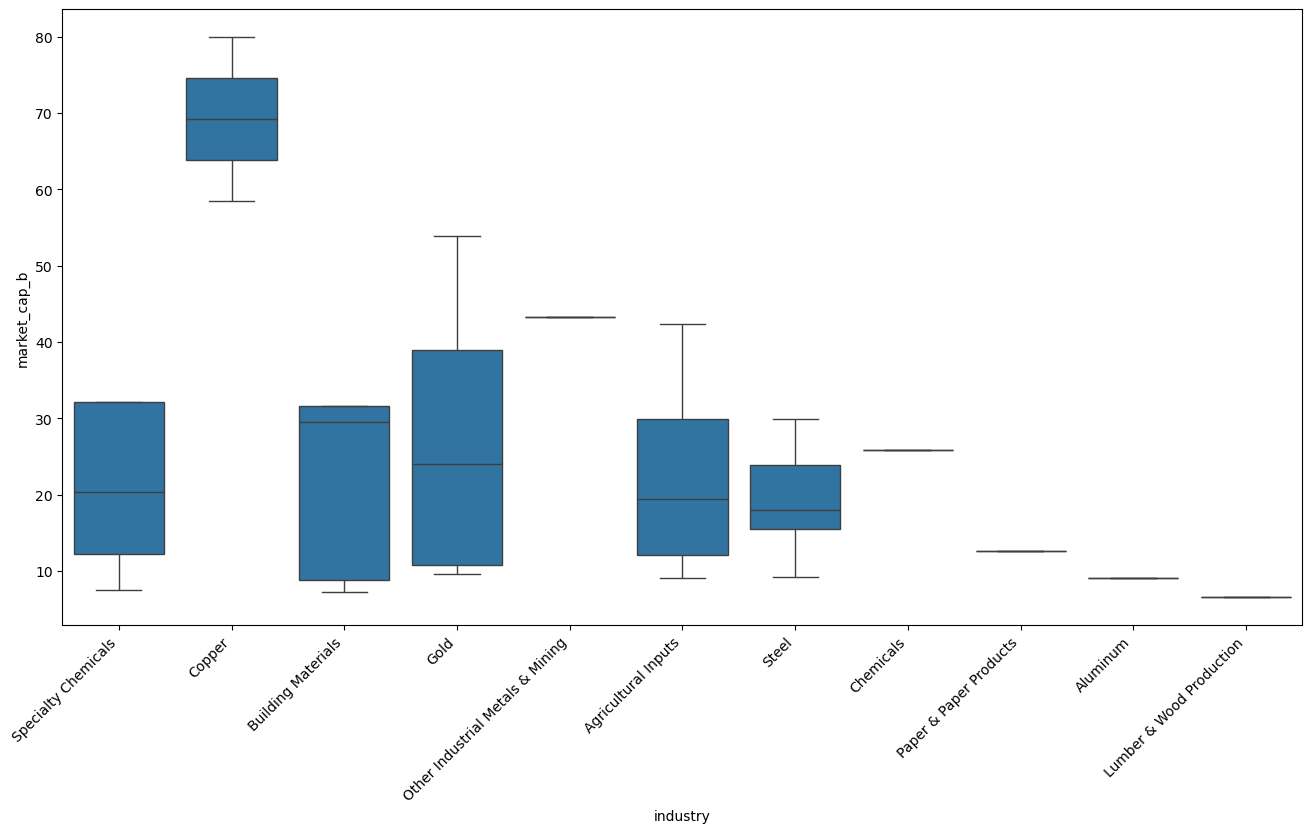

In [140]:
#4
#boxplot
import seaborn as sns
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="market_cap_b",
    showfliers=False
)

plt.xticks(rotation=45, ha='right', fontsize=10) #clearer text, rotate

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Specialty Chemicals'),
  Text(1, 0, 'Copper'),
  Text(2, 0, 'Building Materials'),
  Text(3, 0, 'Gold'),
  Text(4, 0, 'Other Industrial Metals & Mining'),
  Text(5, 0, 'Agricultural Inputs'),
  Text(6, 0, 'Steel'),
  Text(7, 0, 'Chemicals'),
  Text(8, 0, 'Paper & Paper Products'),
  Text(9, 0, 'Aluminum'),
  Text(10, 0, 'Lumber & Wood Production')])

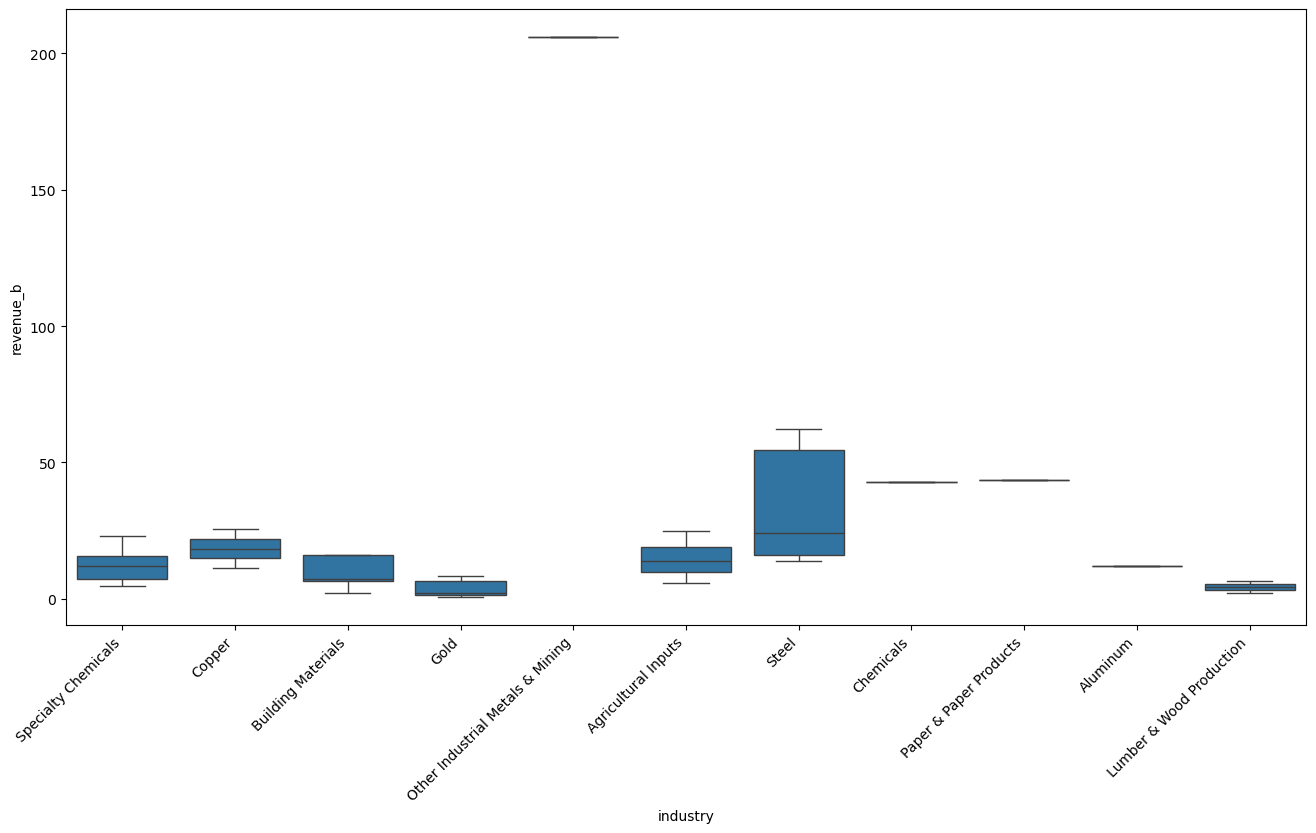

In [141]:
#boxplot revenue
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="revenue_b",
    showfliers=False
)

plt.xticks(rotation=45, ha='right', fontsize=10)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Specialty Chemicals'),
  Text(1, 0, 'Copper'),
  Text(2, 0, 'Building Materials'),
  Text(3, 0, 'Gold'),
  Text(4, 0, 'Other Industrial Metals & Mining'),
  Text(5, 0, 'Agricultural Inputs'),
  Text(6, 0, 'Steel'),
  Text(7, 0, 'Chemicals'),
  Text(8, 0, 'Paper & Paper Products'),
  Text(9, 0, 'Aluminum'),
  Text(10, 0, 'Lumber & Wood Production')])

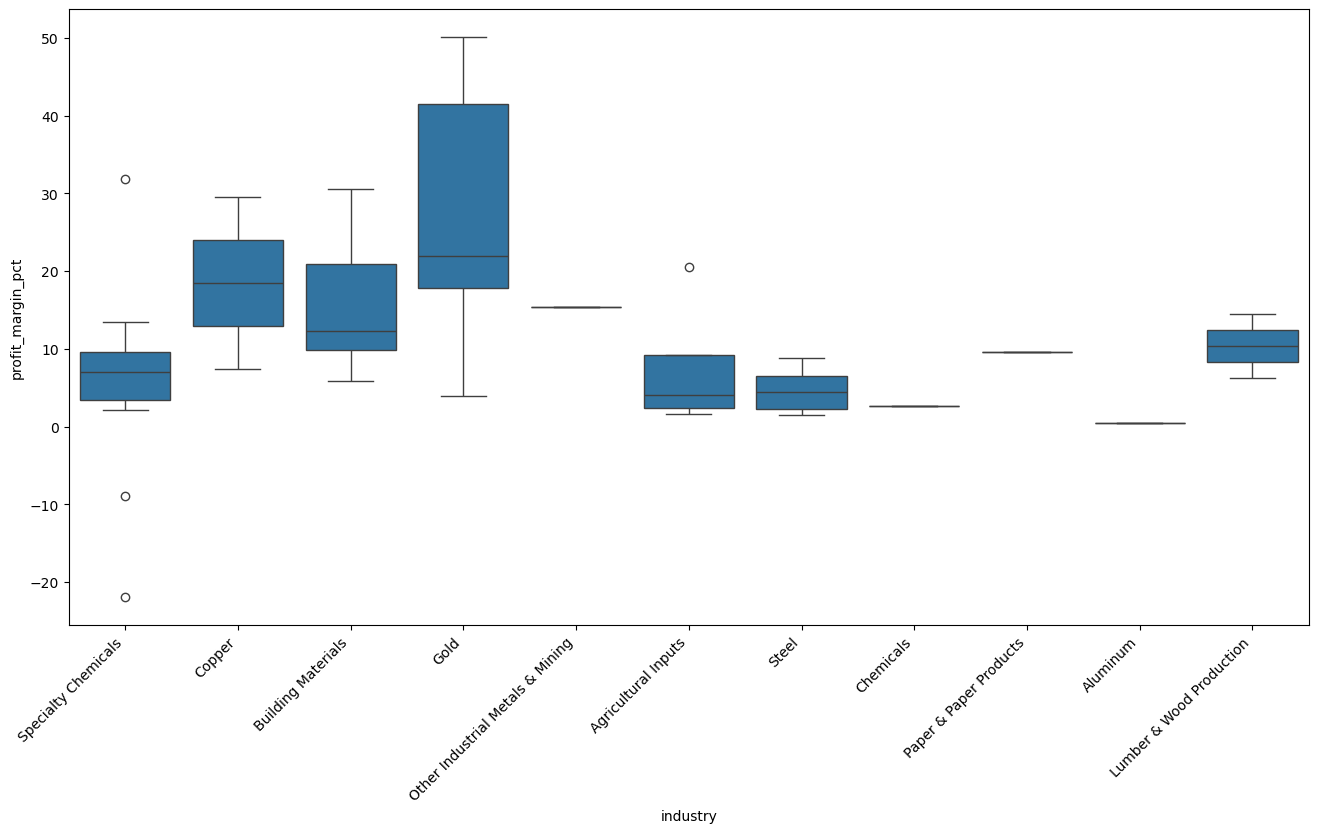

In [142]:

plt.figure(figsize=(16, 8))
sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="profit_margin_pct",
    showfliers=True
)

plt.xticks(rotation=45, ha='right', fontsize=10)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Specialty Chemicals'),
  Text(1, 0, 'Copper'),
  Text(2, 0, 'Building Materials'),
  Text(3, 0, 'Gold'),
  Text(4, 0, 'Other Industrial Metals & Mining'),
  Text(5, 0, 'Agricultural Inputs'),
  Text(6, 0, 'Steel'),
  Text(7, 0, 'Chemicals'),
  Text(8, 0, 'Paper & Paper Products'),
  Text(9, 0, 'Aluminum'),
  Text(10, 0, 'Lumber & Wood Production')])

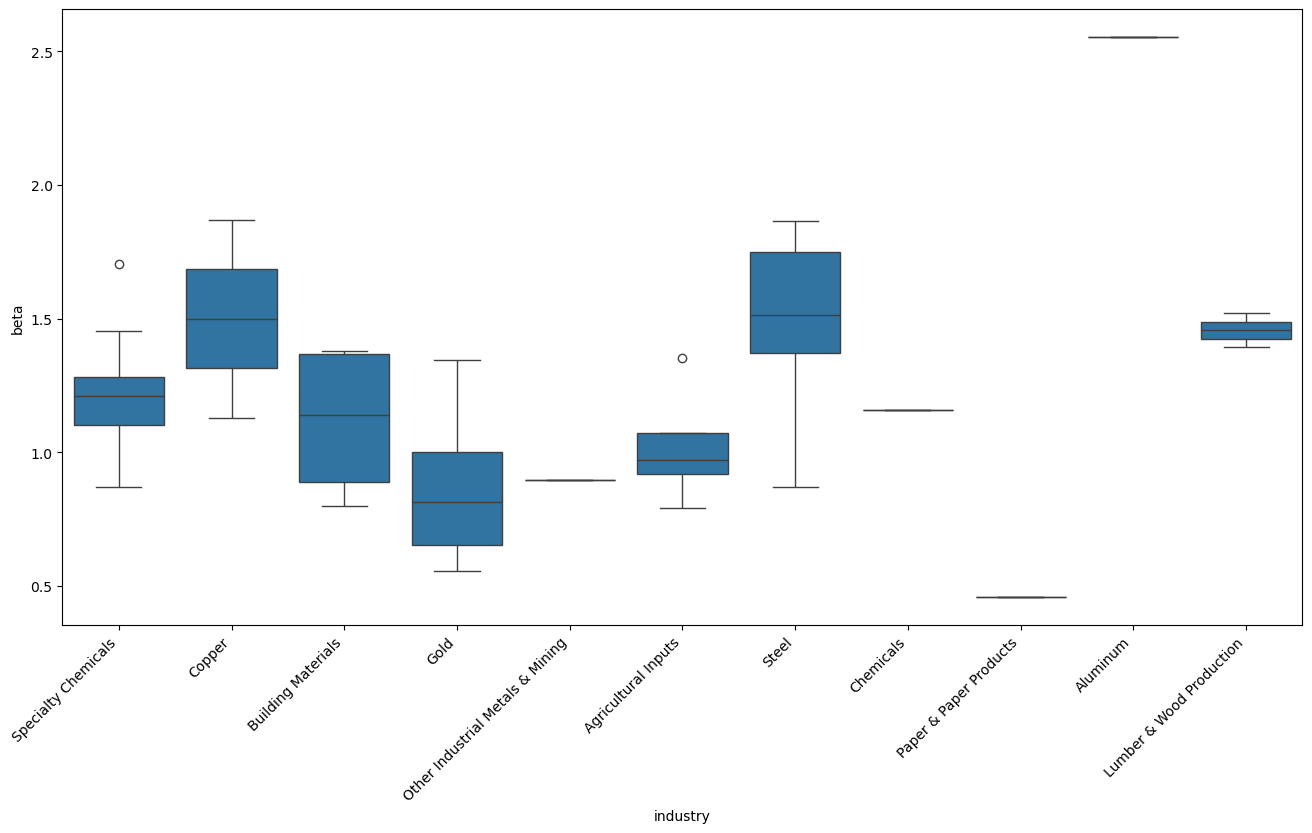

In [143]:
#beta boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="beta",
    showfliers=True
)

plt.xticks(rotation=45, ha='right', fontsize=10)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Specialty Chemicals'),
  Text(1, 0, 'Copper'),
  Text(2, 0, 'Building Materials'),
  Text(3, 0, 'Gold'),
  Text(4, 0, 'Other Industrial Metals & Mining'),
  Text(5, 0, 'Agricultural Inputs'),
  Text(6, 0, 'Steel'),
  Text(7, 0, 'Chemicals'),
  Text(8, 0, 'Paper & Paper Products'),
  Text(9, 0, 'Aluminum'),
  Text(10, 0, 'Lumber & Wood Production')])

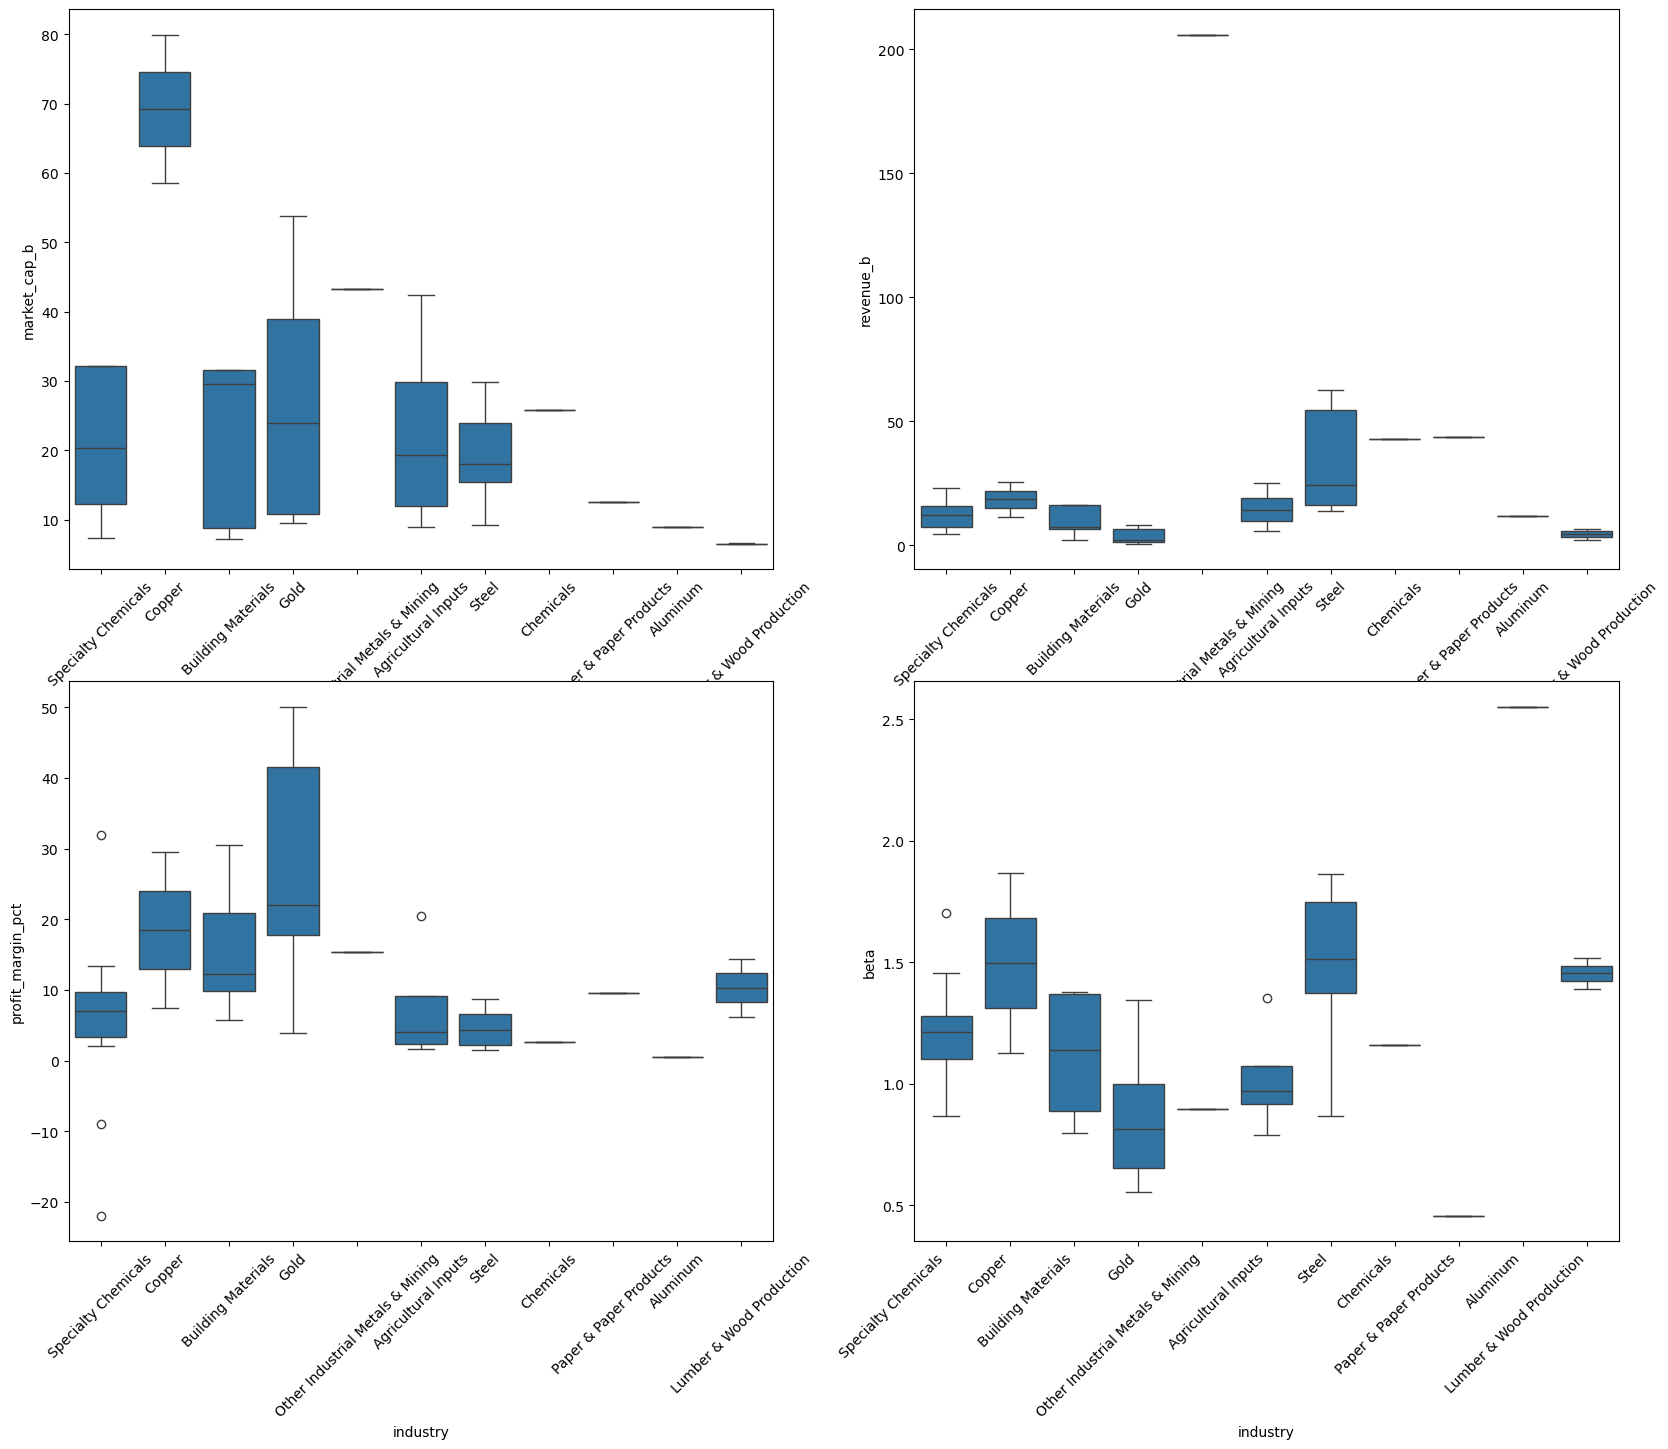

In [144]:
#4
#boxplot
# Create figure with 4 subplots
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(20, 16)
)

# Flatten axes array
axes = axes.flatten()


axes[0]=sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="market_cap_b",
    showfliers=False,
    ax=axes[0]

)

axes[0].tick_params(axis='x', rotation=45, labelsize=10) #clearer text, rotate

#boxplot revenue

axes[1]=sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="revenue_b",
    showfliers=False,
    ax=axes[1]
)

axes[1].tick_params(axis='x', rotation=45, labelsize=10)

#proft


sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="profit_margin_pct",
    showfliers=True,
    ax=axes[2]
)

axes[2].tick_params(axis='x', rotation=45, labelsize=10)

#beta

sns.boxplot(
    data=BM_clean1,
    x="industry",
    y="beta",
    showfliers=True,
    ax=axes[3]
)

plt.xticks(rotation=45, ha='right', fontsize=10)

# step 5
The three industries selected are: Copper, Steel, Specialty Chemicals and Building materials.
Copper: has the highest market cap, its revenue in the middle range compared to the other indusries, profit margins.
Steel: highest revenue, solid market cap.
Specialty chemichals:is stable in a good position in all the aspects.
Building Matrials: moderate position in all aspects.
Gold: low position especially in revenue and market cap, unstable profit and market cap.
Other industrial metals & mining: it is represented only by a line, which indicates that it's represented by a limited number of companies.
Agricultural Inputs:unstable market cap, and relatively low values.
Chemicals: not low positioning, but limited sample size.
Paper & Paper products: limited sampling.
Aluminum: low profit and market cap.
Lumber and Wood Prouction: low in all aspects.

In [188]:
#selecting the companie that are part of the four industries selected
selected_industries = ["Copper", "Steel", "Specialty Chemicals", "Building Materials"]

BM_four = BM_clean1[BM_clean1["industry"].isin(selected_industries)]
print (BM_four)

    symbol                     company_name           sector  \
133    SHW   Sherwin-Williams Company (The)  Basic Materials   
146   SCCO      Southern Copper Corporation  Basic Materials   
168    ECL                      Ecolab Inc.  Basic Materials   
185    CRH                          CRH PLC  Basic Materials   
187    APD  Air Products and Chemicals, Inc  Basic Materials   
203    FCX           Freeport-McMoRan, Inc.  Basic Materials   
342     DD          DuPont de Nemours, Inc.  Basic Materials   
351    VMC  Vulcan Materials Company (Holdi  Basic Materials   
367    NUE                Nucor Corporation  Basic Materials   
370    MLM  Martin Marietta Materials, Inc.  Basic Materials   
407     MT  Arcelor Mittal NY Registry Shar  Basic Materials   
410    PPG             PPG Industries, Inc.  Basic Materials   
431    LYB     LyondellBasell Industries NV  Basic Materials   
486    IFF  International Flavors & Fragran  Basic Materials   
504   STLD             Steel Dynamics, I

# 6 buble chart

Text(-10, -10, 'Low growth\nLow margin')

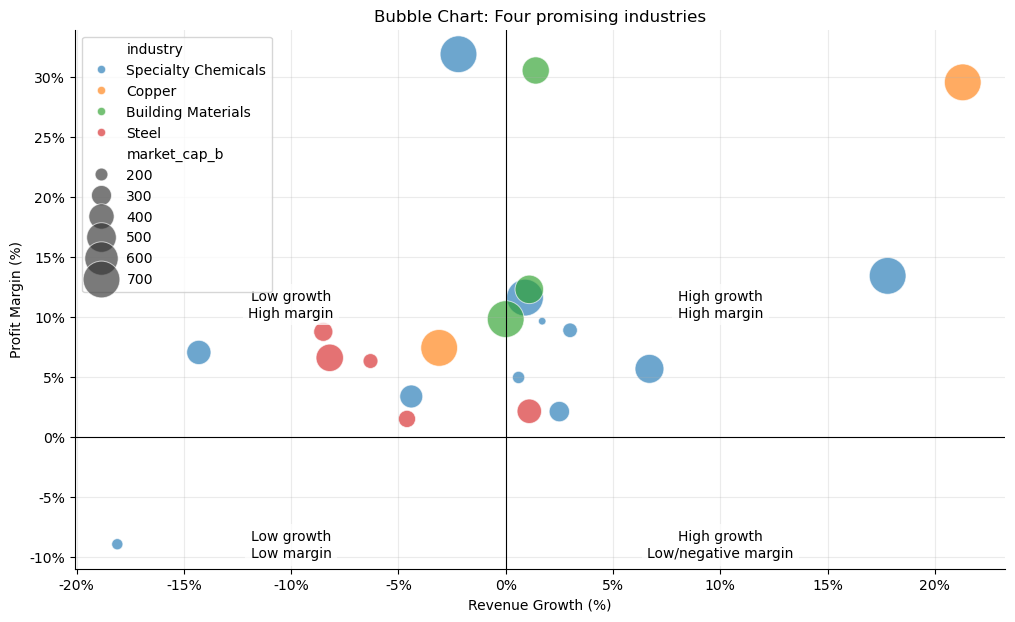

In [146]:
#BM_four
#filtering data 
growth_BM_four = BM_four[
    (BM_four["market_cap_b"] >= 10) &
    (BM_four["revenue_growth_pct"].between(-50, 100)) &
    (BM_four["profit_margin_pct"].between(-50, 80)) &
    (BM_four["beta"].between(0, 3))
].dropna(subset=["revenue_growth_pct", "profit_margin_pct", "beta", "market_cap_b"]).copy()

fig, ax = plt.subplots(figsize=(12, 7))
#making bubles visible and understendable
sizes = (growth_BM_four["market_cap_b"] * 15).clip(lower=30, upper=700)


"""
#points definitions
points = ax.scatter(
    growth_BM_four["revenue_"],
    growth_BM_four["profit_margin_pct"],
    s=sizes,
    c=growth_BM_four["beta"],
    cmap="coolwarm",
    alpha=0.65,
    edgecolors="white",
    linewidth=0.5
)
with this code the companies that look promising have similar betas
"""
sns.scatterplot(
    data=growth_BM_four,
    x="revenue_growth_pct",
    y="profit_margin_pct",
    size=sizes,
    hue="industry", #coloring by industry
    sizes=(30, 700),
    alpha=0.65,
    edgecolor="white"
)
"""
the betas are simmilar so choosing to color the bubbles by  industry seemed appropriate 
to understand how companies from the same industry acted 
according to profit margin and revenue growth.
the sizes have been augmented to better visibility and it represent the market cap
"""
#labels 
ax.set_xlabel("Revenue Growth (%)")
ax.set_ylabel("Profit Margin (%)")
ax.set_title("Bubble Chart: Four promising industries")
ax.xaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(pct_formatter))
ax.grid(alpha=0.25)
clean_spines(ax)
#cbar = plt.colorbar(points, ax=ax)
#cbar.set_label("Beta")

#four quadrants
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)

#adding label for each quadrant
# Add quadrant labels.
ax.text(10, 10, "High growth\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(10, -10, "High growth\nLow/negative margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(-10, 10, "Low growth\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
ax.text(-10, -10, "Low growth\nLow margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))


## 7 zoom quadrant and prices in the last three months


## 7 zoom quadrant and prices last 3 months
the top right quadrant was chosen because most companies have similar market cap and both a positive growth of revenue and a positive profit margins indicating that these are companies are promising in it's growth

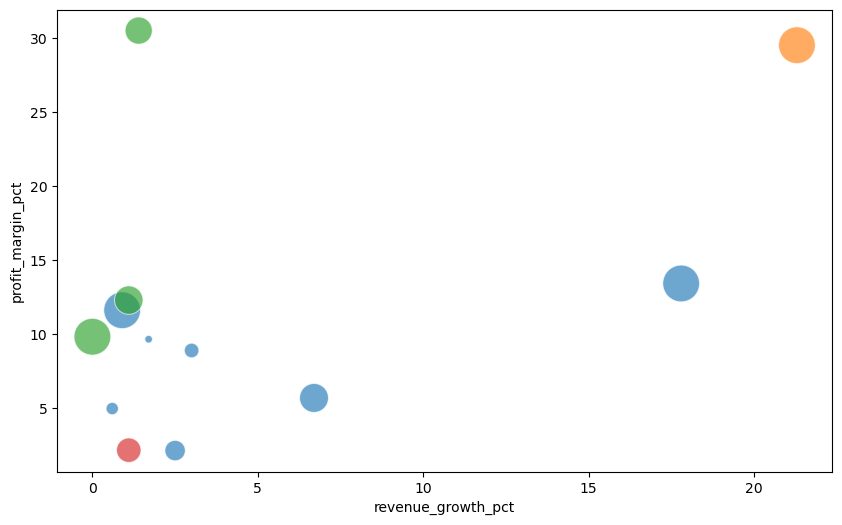

In [147]:
#####reapeating bubble chart####

#zooming the right quadrant
quadrant = growth_BM_four[
    (growth_BM_four["revenue_growth_pct"].between(0, 30)) &
    (growth_BM_four["profit_margin_pct"].between(0, 40))
]
#box
fig, ax = plt.subplots(figsize=(10, 6))
#zoom quadrant 
sns.scatterplot(
    data=quadrant,
    x="revenue_growth_pct",
    y="profit_margin_pct",
    size=sizes,
    hue="industry", #coloring by industry
    sizes=(30, 700),
    alpha=0.65,
    edgecolor="white"
)
#removing legend to better visualize
ax.legend_.remove()



[*********************100%***********************]  10 of 10 completed


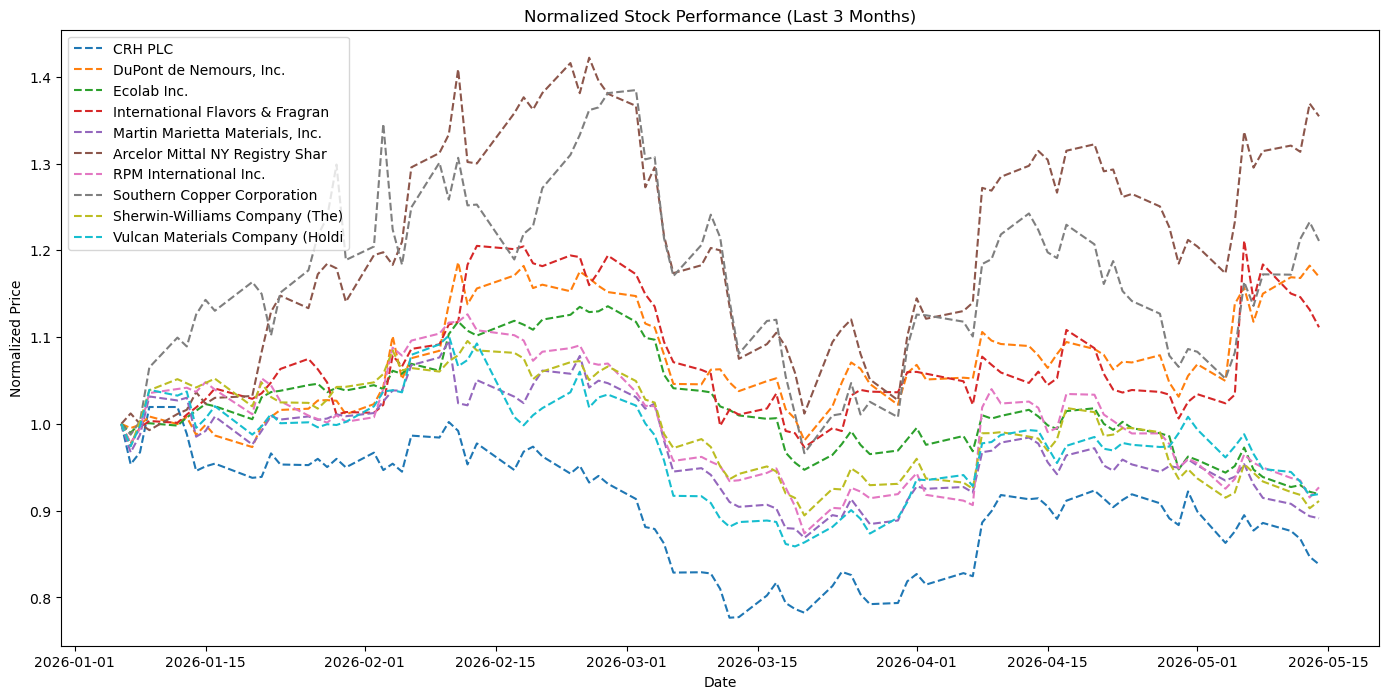

In [180]:
import yfinance as yf
#keeping top 10 companies with highest market cap
short_quadrant=quadrant.sort_values( by="market_cap_b", ascending=False).head(10)

#building tickers
tickers = short_quadrant["symbol"].tolist()
#company name mapping
name_map = short_quadrant.set_index("symbol")["company_name"].to_dict()

#colors to distinguish the different companies
colors = plt.cm.tab10(np.linspace(0, 1, len(normalized.columns)))

#last three months daily prices
prices = yf.download(tickers,period="90d",interval="1d",auto_adjust=True)["Close"]
#normalizing
normalized = prices / prices.iloc[0]

#box
fig, ax = plt.subplots(figsize=(17, 8))

#lines
for i,ticker in enumerate(normalized.columns):
    company_name = name_map[ticker]
    ax.plot(
        normalized.index,
        normalized[ticker],
        color=colors[i],
        linestyle='--',
        linewidth=1.5,
        label=company_name
    )
    
#labels 
plt.title("Normalized Stock Performance (Last 3 Months)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
ax.legend()

## reflection
The tendion in the Strait of Hormuz, might have played an important role on the change in the prices during the last threee months. It can be observed that the growth seen in the beginning of the year has stopped mid February and was followed by a relevant drop of prices for all the companies. However it can be seen that about a month later there hase been an increase in prices even if they have not reached their relative highest points of february. It can be observed that from April there was a divergence between the companies. Some has been having a consistent moderate decrease. While some others have seen a big difference in prices: a drop from the beginning of April and a sudden spike of prices in the beginning of May. 

# 8 COMPARING

Text(-10, 10, 'Low growth\nHigh margin')

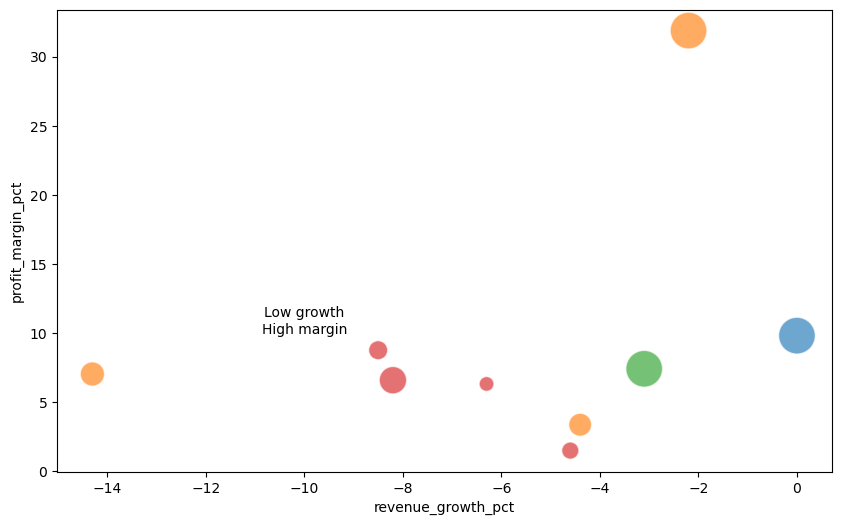

In [182]:
#zooming the right quadrant
quadrant_left = growth_BM_four[
    (growth_BM_four["revenue_growth_pct"].between(-30, 0)) &
    (growth_BM_four["profit_margin_pct"].between(0, 40))
]
#box
fig, ax = plt.subplots(figsize=(10, 6))
#zoom quadrant 
sns.scatterplot(
    data=quadrant_left,
    x="revenue_growth_pct",
    y="profit_margin_pct",
    size=sizes,
    hue="industry", #coloring by industry
    sizes=(30, 700),
    alpha=0.65,
    edgecolor="white"
)
#removing legend to better visualize
ax.legend_.remove()
ax.text(-10, 10, "Low growth\nHigh margin", fontsize=10, ha="center", bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

[*********************100%***********************]  9 of 9 completed


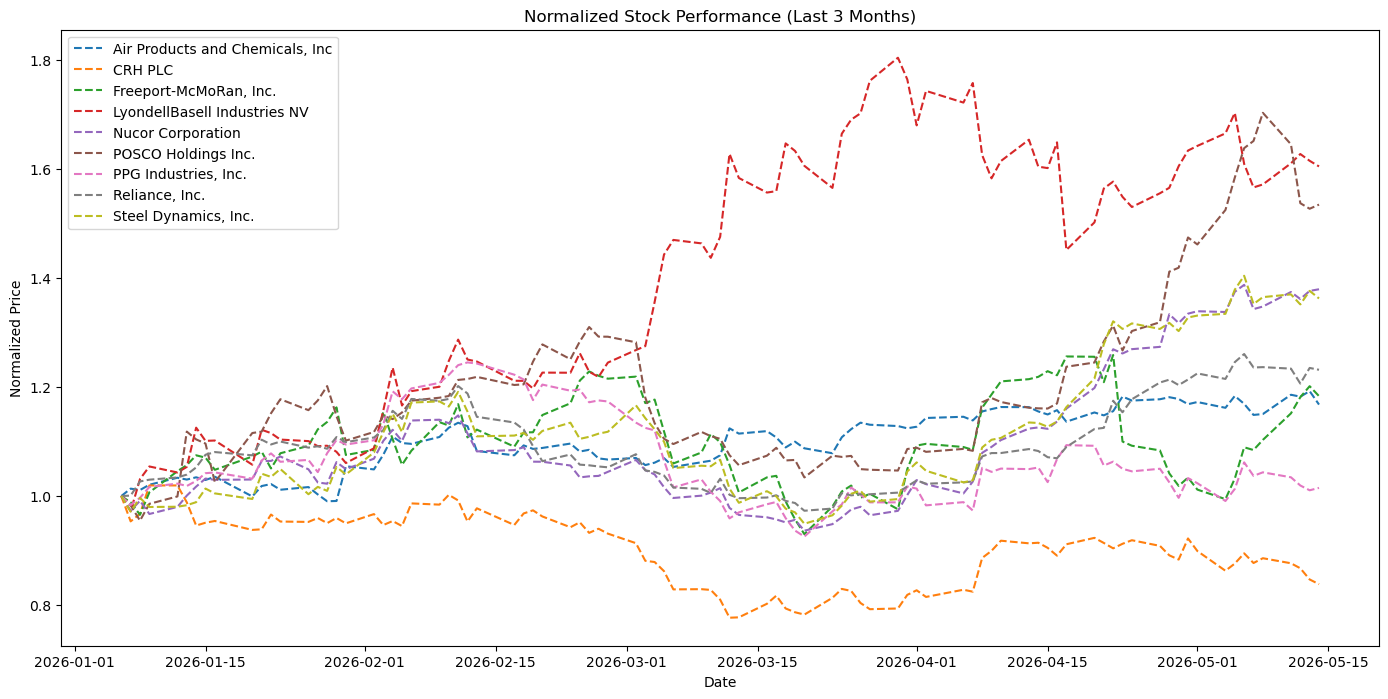

In [183]:
#there are less than 10 companies so no filtering is needed
#building tickers
tickers = quadrant_left["symbol"].tolist()
#company name mapping
name_map = quadrant_left.set_index("symbol")["company_name"].to_dict()

#colors to distinguish the different companies
colors = plt.cm.tab10(np.linspace(0, 1, len(normalized.columns)))

#last three months daily prices
prices = yf.download(tickers,period="90d",interval="1d",auto_adjust=True)["Close"]
#normalizing
normalized = prices / prices.iloc[0]

#box
fig, ax = plt.subplots(figsize=(17, 8))

#lines
for i,ticker in enumerate(normalized.columns):
    company_name = name_map[ticker]
    ax.plot(
        normalized.index,
        normalized[ticker],
        color=colors[i],
        linestyle='--',
        linewidth=1.5,
        label=company_name
    )
    
#labels 
plt.title("Normalized Stock Performance (Last 3 Months)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
ax.legend()

## comparison
In both quadrants we can see we can see a moderate growth of prices till March. However in the left quadrant there is a more uniform growth compared to the right quadrant. There is also a more delayed and more moderate fall of prices, with only an exception, LyondellBasel Industries NV, who has seen a drastic change growth of prices since March, with a moderatefall of prices from April. Nucor Corporation sees from april a drastic growth in price. Compared to before from April we can see a similar moderate growth of prices. However,similarly to the other quadrant,  from half April there has been a divergence in price changes between companies some are growing and others are decresing.
From this comparison, it can be observed how both group of companies where affected from the geopolitical situation. The companies with lower revenue growth have been affected less compared to the ones with a higher revenue growth.


# Final Summary
OVERALL STRUCTURE OF THE BASIC MATERIALS
-The size of the sector is very small with only 45 companies out of 10000.
-there is a decent to solid positive margin profitability, with all ranging between 5% and 15%.

INDUSTRY CHOICE
The three industries selected are: Copper, Steel, Specialty Chemicals and Building materials
Copper: has the highest market cap, its revenue in the middle range compared to the other indusries, profit margins 
Steel: highest revenue, solid market cap, 
Specialty chemichals:is stable in a good position in all the aspects
Building Matrials: moderate position in all aspects
Gold: low position especially in revenue and market cap, unstable profit and market cap
Other industrial metals & mining: it is represented only by a line, which indicates that it's represented by a limited number of companies
Agricultural Inputs:unstable market cap, and relatively low values
Chemicals: not low positioning, but limited sample size
Paper & Paper products: limited sampling
Aluminum: low profit and market cap
Lumber and Wood Prouction: low in all aspects

BUBBLE CHART
-Most companies of the four industries have a positive profit margin while the revenue growth ranges between -20% to 20%. steel industries tend to have a negative revenue growth.specialty chemicals tent to have a positive revenue growth.building materials have a little growth revenue close to 0%. companies have a small market cap.

PERFORMACE LAST 3 MONTHS
the performance of companies have been affected form the geopolitical context as expected. In March there has been a moderate growth. Theleft quadrant has been less affetcted than the right one. the left quadrant have proved to be more resilient than the right quadrant which was more affected.
